In [1]:
!pip install opencv-python pillow tqdm pandas



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 47.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 52.2 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.17.0 requires numpy<2.0.0,>=1.23.5; python_version <= "3.11", but you have numpy 2.2.6 which is incompatible.

[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
!apt-get update && apt-get install -y libgl1-mesa-glx

Get:1 http://archive.ubuntu.com/ubuntu jammy InRelease [270 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]        
Get:3 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]      
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1581 B]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]      
Get:6 http://archive.ubuntu.com/ubuntu jammy/multiverse amd64 Packages [266 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy/restricted amd64 Packages [164 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy/universe amd64 Packages [17.5 MB]
Get:9 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1927 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy/main amd64 Packages [1792 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [5299 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [48.5 k

In [3]:
!pip install pyyaml


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 763.0/763.0 kB 25.2 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [4]:
!pip install -U ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 42.6 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [17]:
from pathlib import Path
import cv2, numpy as np, pandas as pd, hashlib, csv, random, traceback, yaml
from tqdm import tqdm
from IPython.display import display, Image as IPyImage

In [23]:
# ===================================================================
# CELL 1: SETUP AND CONFIGURATION (UPDATED)
# ===================================================================
import yaml
from pathlib import Path
import pandas as pd
import cv2
import numpy as np
from tqdm.notebook import tqdm
import traceback
import csv
import hashlib

# --- Configuration ---
# Root folder for your original spectrograms
INPUT_DIR = Path("/workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project/Processed")

# Root folder for the new, clean images
OUTPUT_DIR = Path("data/processed_harmonised")

# Processing parameters collected in a dictionary
CFG = {
    "size": 224,           # target square size
    "crop_thresh": 5,      # pixels <= thresh treated as border
    "manifest": "metadata_harmonised.csv",
    "out_ext": ".png"      # <-- The missing key has been added here
}

# --- Preparation ---
# Create the output directory if it doesn't exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save a snapshot of the configuration for reproducibility
config_path = OUTPUT_DIR / "harmonise_config.yaml"
with open(config_path, "w") as f:
    yaml.safe_dump(CFG, f, sort_keys=False)

print("✅ Configuration loaded and saved to:")
print(config_path)

✅ Configuration loaded and saved to:
data/processed_harmonised/harmonise_config.yaml


In [24]:
# ===================================================================
# CELL 2: HELPER FUNCTIONS
# ===================================================================
import cv2
import numpy as np
import hashlib
from pathlib import Path

# --- Low-level helpers ---

def sha1_bytes(x: bytes) -> str:
    return hashlib.sha1(x).hexdigest()

def to_grayscale(img):
    if img.ndim == 2:
        return img.astype(np.uint8)
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

def crop_borders(gray: np.ndarray, thresh: int) -> np.ndarray:
    mask = gray > thresh
    if not mask.any(): return gray
    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max() + 1
    x0, x1 = xs.min(), xs.max() + 1
    return gray[y0:y1, x0:x1]

def robust_norm_0_255(gray: np.ndarray) -> np.ndarray:
    lo, hi = np.percentile(gray, 1.0), np.percentile(gray, 99.0)
    if hi <= lo:
        lo, hi = float(gray.min()), float(gray.max())
        if hi <= lo: return np.zeros_like(gray, dtype=np.uint8)
    norm = np.clip((gray - lo) / (hi - lo), 0, 1)
    return (norm * 255).astype(np.uint8)

def center_pad_to_square(gray: np.ndarray) -> np.ndarray:
    h, w = gray.shape[:2]
    if h == w: return gray
    s = max(h, w)
    canvas = np.zeros((s, s), dtype=gray.dtype)
    y0, x0 = (s - h)//2, (s - w)//2
    canvas[y0:y0+h, x0:x0+w] = gray
    return canvas

# --- High-level processing function for one image ---

def harmonise_one(in_path: Path, out_path: Path, cfg: dict):
    img = cv2.imread(str(in_path), cv2.IMREAD_UNCHANGED)
    if img is None:
        raise ValueError("Cannot read image")

    gray = to_grayscale(img)
    gray = crop_borders(gray, cfg["crop_thresh"])
    gray = robust_norm_0_255(gray)
    gray = center_pad_to_square(gray)
    gray = cv2.resize(gray, (cfg["size"], cfg["size"]), interpolation=cv2.INTER_AREA)

    out_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(out_path.with_suffix(cfg["out_ext"])), gray)

    with open(in_path, "rb") as f:
        src_sha = sha1_bytes(f.read())
    _, buf = cv2.imencode(cfg["out_ext"], gray)
    dst_sha = sha1_bytes(buf.tobytes())
    return src_sha, dst_sha, gray.shape

print("✅ Helper functions defined.")

✅ Helper functions defined.


In [20]:
# ===================================================================
# CELL 3: MAIN PROCESSING LOOP (WITH IMPORTS)
# ===================================================================
import pandas as pd
import traceback
import csv
from tqdm.notebook import tqdm # Ensures the progress bar library is loaded

# 1. Gather all image files from the input directory
exts = {".png", ".jpg", ".jpeg", ".bmp", ".webp"}
files_to_process = [p for p in INPUT_DIR.rglob("*") if p.suffix.lower() in exts]
print(f"Found {len(files_to_process)} images to harmonise.")

manifest_data = []
errors = []

# 2. Loop through and process each file
for in_path in tqdm(files_to_process, desc="Harmonising images"):
    try:
        # Define the output path, preserving the subfolder structure
        relative_path = in_path.relative_to(INPUT_DIR)
        out_path = OUTPUT_DIR / relative_path

        # Call the main processing function for one image
        src_sha, dst_sha, shape = harmonise_one(in_path, out_path, CFG)
        
        manifest_data.append({
            "original_filepath": str(in_path),
            "harmonised_filepath": str(out_path.with_suffix(CFG["out_ext"])),
            "label": in_path.parent.name, # Assumes folder name is the label
            "src_sha1": src_sha,
            "dst_sha1": dst_sha
        })
        
    except Exception as e:
        print(f"Error processing {in_path}: {e}")
        errors.append({"filepath": str(in_path), "error": str(e)})

# --- FINALISE ---
# 3. Create the new metadata file for the harmonised dataset
if manifest_data:
    manifest_df = pd.DataFrame(manifest_data)
    manifest_path = OUTPUT_DIR / CFG["manifest"]
    manifest_df.to_csv(manifest_path, index=False)
    print(f"\n✅ Done. Harmonised images saved in: {OUTPUT_DIR}")
    print(f"🗂️  New metadata saved to: {manifest_path}")

if errors:
    error_df = pd.DataFrame(errors)
    error_path = OUTPUT_DIR / "harmonise_errors.csv"
    error_df.to_csv(error_path, index=False)
    print(f"\n⚠️  {len(errors)} files failed to process. See error log: {error_path}")

Found 3601 images to harmonise.


Harmonising images:   0%|          | 0/3601 [00:00<?, ?it/s]


✅ Done. Harmonised images saved in: data/processed_harmonised
🗂️  New metadata saved to: data/processed_harmonised/metadata_harmonised.csv


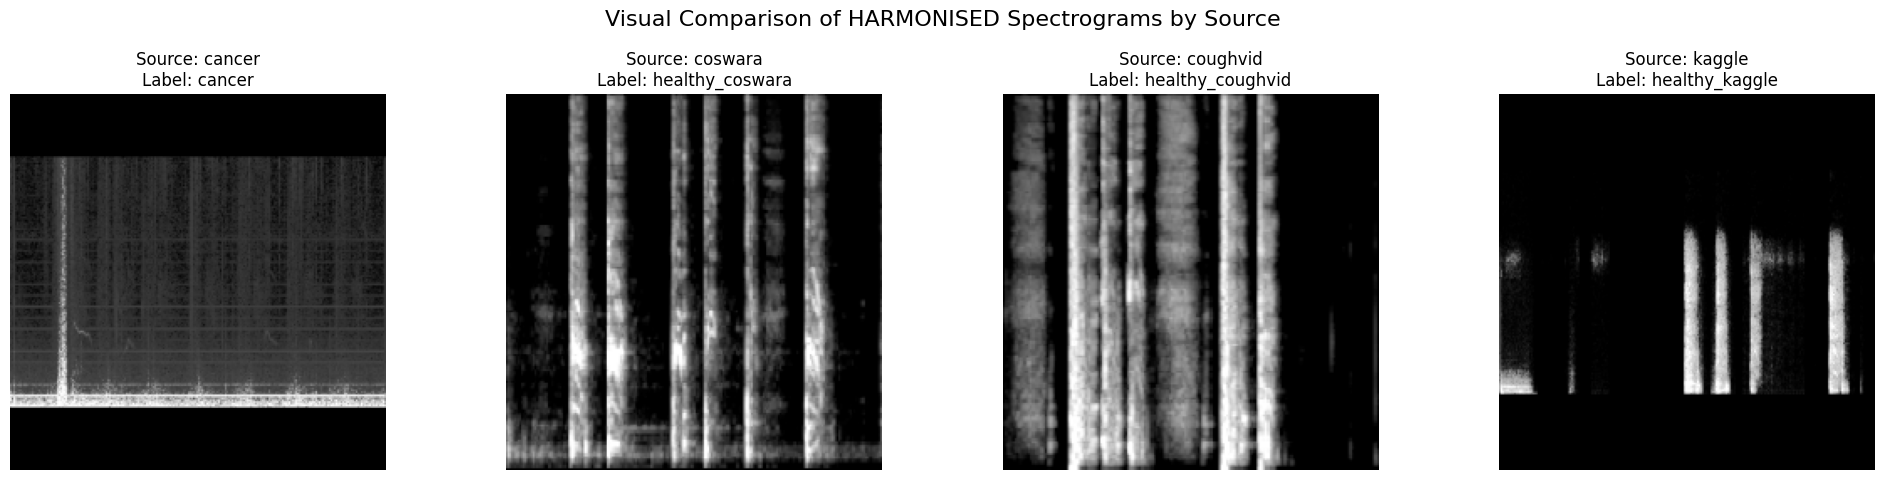

In [21]:
# ===================================================================
# CELL: VERIFY HARMONISATION
# ===================================================================
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

# 1. Load the NEW metadata for the harmonised dataset
METADATA_CSV = "data/processed_harmonised/metadata_harmonised.csv"
metadata = pd.read_csv(METADATA_CSV)

# 2. Re-create a 'source' column for plotting purposes
# We can determine the source from the original filepath structure
def get_source_from_path(path_str):
    folder_name = Path(path_str).parent.name
    if 'coswara' in folder_name: return 'coswara'
    if 'coughvid' in folder_name: return 'coughvid'
    if 'kaggle' in folder_name: return 'kaggle'
    if 'cancer' in folder_name: return 'cancer'
    return 'unknown'

metadata['source'] = metadata['original_filepath'].apply(get_source_from_path)
sources = sorted(metadata['source'].unique())

# 3. Create the plot
fig, axes = plt.subplots(1, len(sources), figsize=(20, 5))
fig.suptitle('Visual Comparison of HARMONISED Spectrograms by Source', fontsize=16)

for i, source in enumerate(sources):
    # Get one random sample from the current source
    sample = metadata[metadata['source'] == source].sample(n=1, random_state=42).iloc[0]
    
    # Use the NEW 'harmonised_filepath' column
    img_path = Path(sample['harmonised_filepath'])
    
    img = Image.open(img_path)
    ax = axes[i]
    ax.imshow(img, cmap='gray') # Display in grayscale
    ax.set_title(f"Source: {source}\nLabel: {sample['label']}")
    ax.axis('off')
            
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

--- Testing Harmonization WITHOUT Border Cropping ---


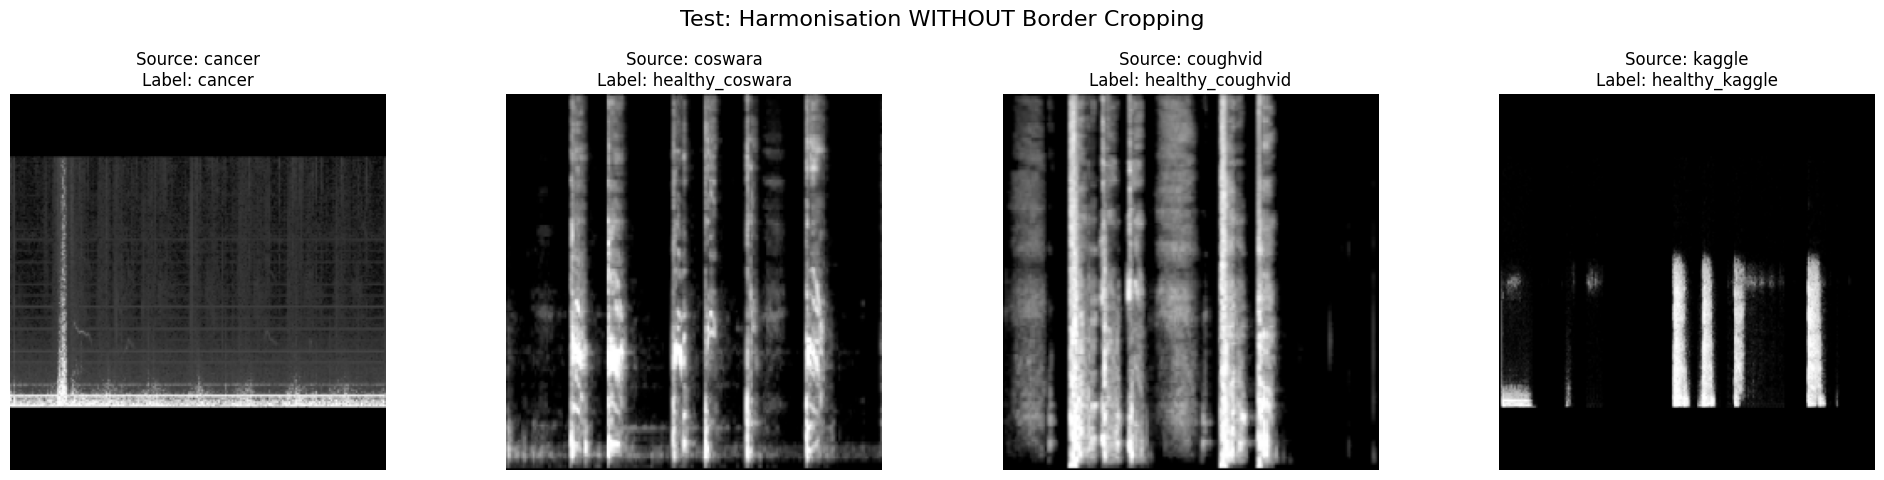

In [26]:
# ===================================================================
# CELL: All-in-One Test for Disabling Border Crop
# ===================================================================
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import numpy as np

# --- Configuration (from Cell 1) ---
TARGET_SIZE = 224
CROP_THRESHOLD = 5 # Even though we are not using it, it's good practice to keep it here

# --- Helper Functions (from Cell 2) ---
def to_grayscale(img_bgr: np.ndarray) -> np.ndarray:
    """Converts a BGR or single-channel image to a uint8 grayscale image."""
    if img_bgr.ndim == 2:
        return img_bgr.astype(np.uint8)
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

def normalise_0_255(gray: np.ndarray) -> np.ndarray:
    """Performs a robust min-max normalisation to the 0-255 range."""
    lo = np.percentile(gray, 1.0)
    hi = np.percentile(gray, 99.0)
    if hi <= lo:
        lo, hi = float(gray.min()), float(gray.max())
        if hi <= lo:
            return np.zeros_like(gray, dtype=np.uint8)
    norm = np.clip((gray - lo) / (hi - lo), 0, 1)
    return (norm * 255).astype(np.uint8)

def center_pad_to_square(gray: np.ndarray) -> np.ndarray:
    """Pads an image to be square while maintaining its aspect ratio."""
    h, w = gray.shape[:2]
    if h == w:
        return gray
    s = max(h, w)
    canvas = np.zeros((s, s), dtype=gray.dtype)
    y0 = (s - h) // 2
    x0 = (s - w) // 2
    canvas[y0:y0+h, x0:x0+w] = gray
    return canvas

# --- Test Script ---
print("--- Testing Harmonization WITHOUT Border Cropping ---")

# 1. Load metadata to find the original paths of our sample files
METADATA_CSV = "data/processed_harmonised/metadata_harmonised.csv"
metadata = pd.read_csv(METADATA_CSV)

# Re-create the 'source' column to select our samples
def get_source_from_path(path_str):
    folder_name = Path(path_str).parent.name
    if 'coswara' in folder_name: return 'coswara'
    if 'coughvid' in folder_name: return 'coughvid'
    if 'kaggle' in folder_name: return 'kaggle'
    if 'cancer' in folder_name: return 'cancer'
    return 'unknown'

metadata['source'] = metadata['original_filepath'].apply(get_source_from_path)
sources = sorted(metadata['source'].unique())

# 2. Setup the plot
fig, axes = plt.subplots(1, len(sources), figsize=(20, 5))
fig.suptitle('Test: Harmonisation WITHOUT Border Cropping', fontsize=16)

# 3. Loop through the sources and process one sample from each
for i, source in enumerate(sources):
    sample = metadata[metadata['source'] == source].sample(n=1, random_state=42).iloc[0]
    img_path = Path(sample['original_filepath'])

    # --- Modified Harmonisation Pipeline ---
    img = cv2.imread(str(img_path))
    gray = to_grayscale(img)
    # The crop_borders() step is SKIPPED!
    gray = normalise_0_255(gray)
    gray = center_pad_to_square(gray)
    processed_img = cv2.resize(gray, (TARGET_SIZE, TARGET_SIZE), interpolation=cv2.INTER_AREA)
    
    # --- Display the result ---
    ax = axes[i]
    ax.imshow(processed_img, cmap='gray')
    ax.set_title(f"Source: {source}\nLabel: {sample['label']}")
    ax.axis('off')
            
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

--- Displaying a sample of ORIGINAL, UNTOUCHED images ---


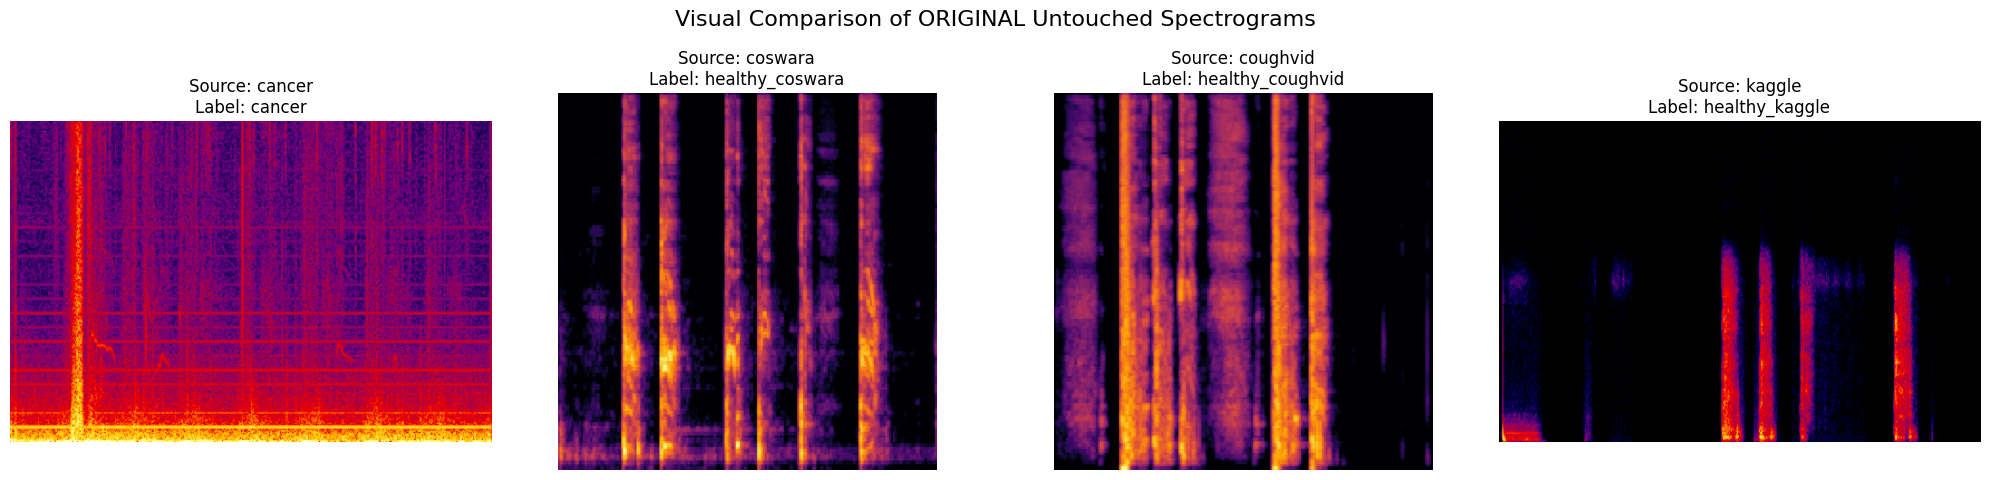

In [27]:
# ===================================================================
# CELL: VIEW ORIGINAL UNTOUCHED IMAGES
# ===================================================================
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

print("--- Displaying a sample of ORIGINAL, UNTOUCHED images ---")

# 1. Load metadata to find the original paths
METADATA_CSV = "data/processed_harmonised/metadata_harmonised.csv"
metadata = pd.read_csv(METADATA_CSV)

# Re-create the 'source' column to select our samples
def get_source_from_path(path_str):
    folder_name = Path(path_str).parent.name
    if 'coswara' in folder_name: return 'coswara'
    if 'coughvid' in folder_name: return 'coughvid'
    if 'kaggle' in folder_name: return 'kaggle'
    if 'cancer' in folder_name: return 'cancer'
    return 'unknown'

metadata['source'] = metadata['original_filepath'].apply(get_source_from_path)
sources = sorted(metadata['source'].unique())

# 2. Setup the plot
fig, axes = plt.subplots(1, len(sources), figsize=(20, 5))
fig.suptitle('Visual Comparison of ORIGINAL Untouched Spectrograms', fontsize=16)

# 3. Loop through and display one original sample from each
for i, source in enumerate(sources):
    sample = metadata[metadata['source'] == source].sample(n=1, random_state=42).iloc[0]
    # Use the ORIGINAL image path for this test
    img_path = Path(sample['original_filepath'])
    
    try:
        img = Image.open(img_path)
        ax = axes[i]
        ax.imshow(img) # Display original image, no colormap change
        ax.set_title(f"Source: {source}\nLabel: {sample['label']}")
        ax.axis('off')
    except FileNotFoundError:
        print(f"File not found: {img_path}")
            
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()